In [2]:
import pandas as pd
df = pd.read_csv("/vol/ideadata/ed52egek/pycharm/syneverything/datasets/ctflow/ctrate_slices_final.csv")
df


,Unnamed: 0,path,Split,id,No Finding,1a,1b,1c,1d,1e,1f,2a,2b,2c,2d,2e,2f,2g,2h
0,0,ctflow_slices/train_1741_b_2_f077.nii.gz.png,TEST,1741,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,1,ctflow_slices/train_1741_b_2_f021.nii.gz.png,TEST,1741,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,ctflow_slices/train_1935_a_1_f123.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,ctflow_slices/train_1935_a_1_f134.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,ctflow_slices/train_1935_a_1_f102.nii.gz.png,TEST,1935,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27678,27678,ctflow_slices/train_13316_a_2_f016.nii.gz.png,TRAIN,13316,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
27679,27679,ctflow_slices/train_13339_a_1_f226.nii.gz.png,TRAIN,13339,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
27680,27680,ctflow_slices/train_13339_a_1_f164.nii.gz.png,TRAIN,13339,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
27681,27681,ctflow_slices/train_13339_a_1_f084.nii.gz.png,TRAIN,13339,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
df_l = df[["No Finding","1a","1b", "1c","1d","1e","1f","2a", "2b","2c","2d","2e","2f","2g","2h"]]
df = df[df_l.sum(axis=1) == 1]
df.reset_index(drop=True)
df = df.drop(columns={"Unnamed: 0"})
df

,path,Split,id,No Finding,1a,1b,1c,1d,1e,1f,2a,2b,2c,2d,2e,2f,2g,2h
0,ctflow_slices/train_1741_b_2_f077.nii.gz.png,TEST,1741,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,ctflow_slices/train_1741_b_2_f021.nii.gz.png,TEST,1741,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ctflow_slices/train_1935_a_1_f123.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,ctflow_slices/train_1935_a_1_f134.nii.gz.png,TEST,1935,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ctflow_slices/train_1935_a_1_f102.nii.gz.png,TEST,1935,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27678,ctflow_slices/train_13316_a_2_f016.nii.gz.png,TRAIN,13316,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
27679,ctflow_slices/train_13339_a_1_f226.nii.gz.png,TRAIN,13339,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
27680,ctflow_slices/train_13339_a_1_f164.nii.gz.png,TRAIN,13339,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
27681,ctflow_slices/train_13339_a_1_f084.nii.gz.png,TRAIN,13339,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
df["id"].nunique()

2652

# Full dataset

Split Distribution:
    Split  Count
0  TRAIN  13309
1   TEST   6767
2    VAL   2229

Class Distribution:
          Class  Count
0   No Finding   7802
9           2c   3509
10          2d   2518
8           2b   2428
7           2a   2064
3           1c   1308
5           1e    580
1           1a    564
2           1b    521
4           1d    366
6           1f    286
11          2e    276
14          2h     48
13          2g     19
12          2f     16


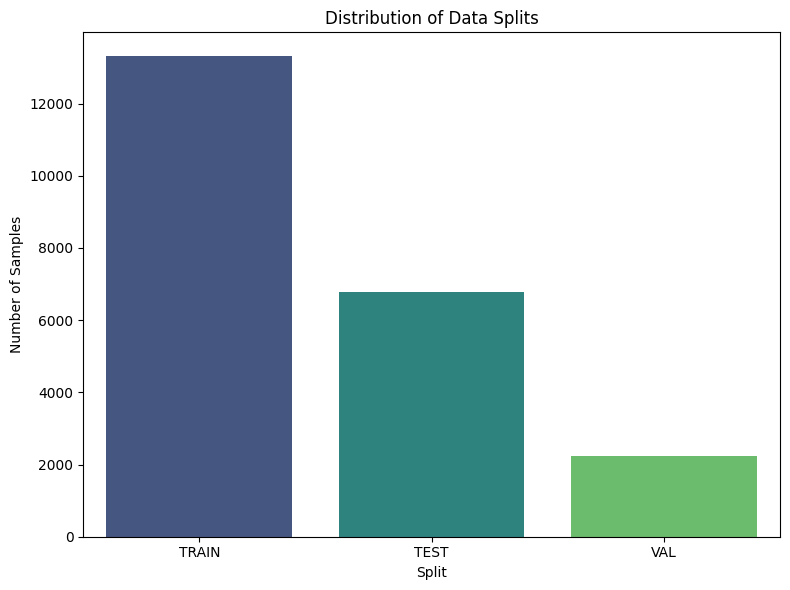

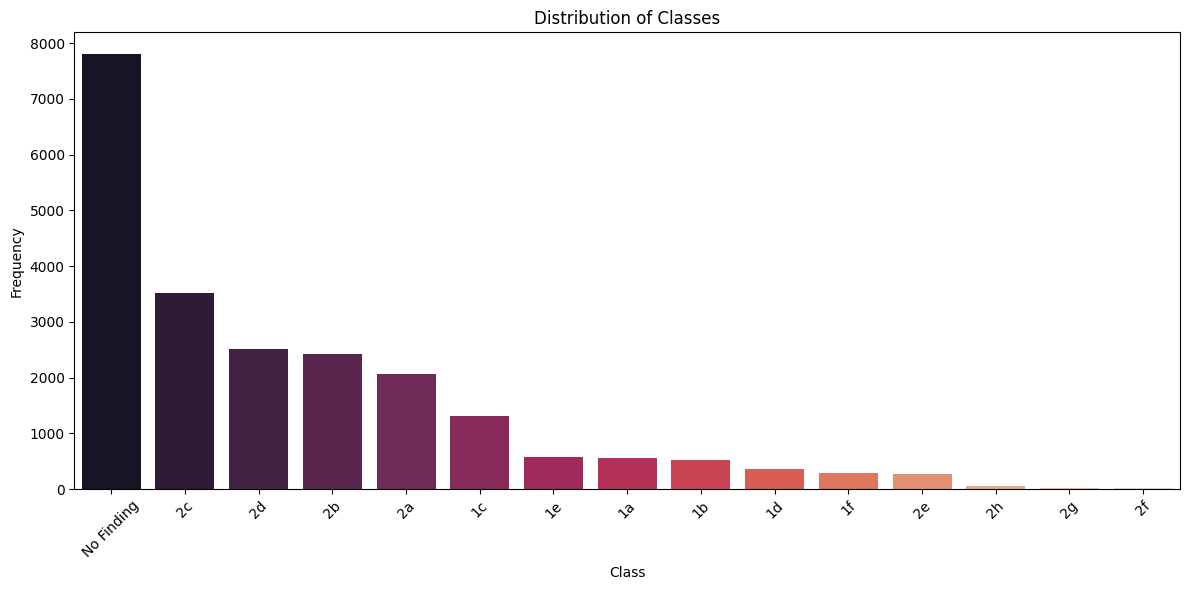

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is named 'df'
# Define the class columns based on your provided structure
class_cols = ['No Finding', '1a', '1b', '1c', '1d', '1e', '1f', 
              '2a', '2b', '2c', '2d', '2e', '2f', '2g', '2h']

# 1. Compute and Visualize Split Distribution
split_dist = df['Split'].value_counts().reset_index()
split_dist.columns = ['Split', 'Count']
split_dist = split_dist.sort_values(by='Count', ascending=False)

fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.barplot(data=split_dist, x='Split', y='Count', ax=ax1, hue='Split', palette='viridis')
ax1.set_title('Distribution of Data Splits')
ax1.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('split_distribution.png')

# 2. Compute and Visualize Class Distribution
# Summing binary columns to get the total count per class
class_counts = df[class_cols].sum().reset_index()
class_counts.columns = ['Class', 'Count']
class_counts = class_counts.sort_values(by='Count', ascending=False)

fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(data=class_counts, x='Class', y='Count', ax=ax2, hue='Class', palette='rocket')
ax2.set_title('Distribution of Classes')
ax2.set_ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png')

# Display numeric summaries
print("Split Distribution:\n", split_dist)
print("\nClass Distribution:\n", class_counts)

## Test Split

Class Distribution for TEST Split:
     Class  Count
No Finding   2407
        2c    978
        2d    755
        2b    693
        2a    636
        1c    391
        1b    227
        1a    196
        1e    175
        1f    115
        1d    106
        2e     68
        2f      8
        2g      6
        2h      6


/tmp/ipykernel_2402270/3477970666.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_class_dist, x='Class', y='Count', palette='magma')


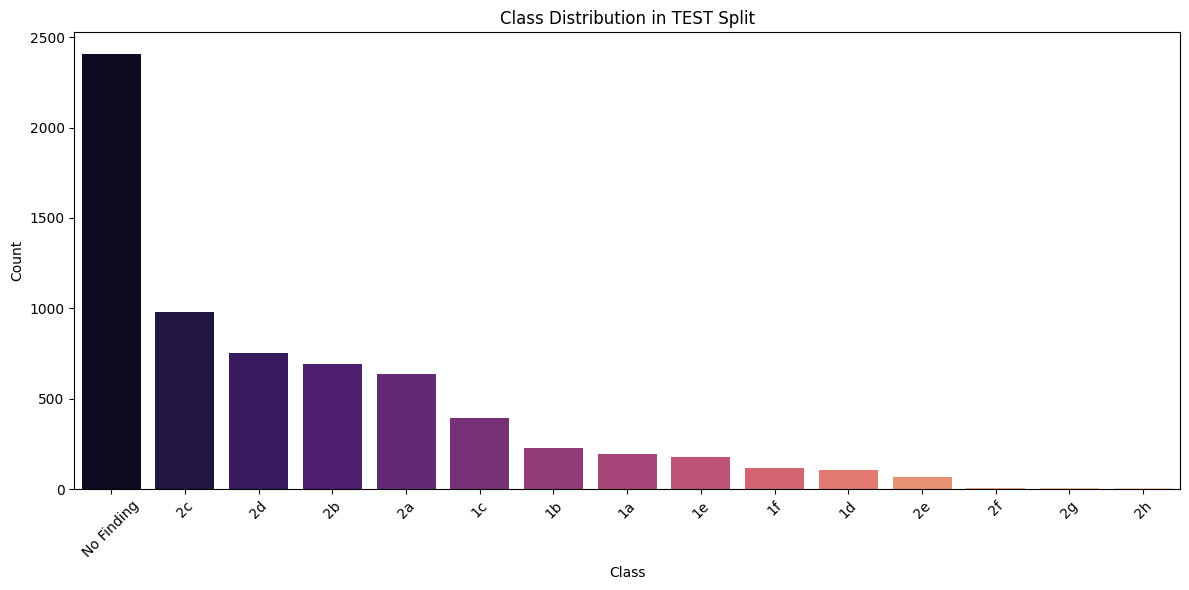

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identify class columns
class_cols = ['No Finding', '1a', '1b', '1c', '1d', '1e', '1f', 
              '2a', '2b', '2c', '2d', '2e', '2f', '2g', '2h']

# 1. Filter the dataframe for the 'TEST' split
test_df = df[df['Split'] == 'TEST']

# 2. Compute Class Distribution for the TEST split
test_class_dist = test_df[class_cols].sum().reset_index()
test_class_dist.columns = ['Class', 'Count']
test_class_dist = test_class_dist.sort_values(by='Count', ascending=False)

# 3. Print the distribution
print("Class Distribution for TEST Split:")
print(test_class_dist.to_string(index=False))

# 4. Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=test_class_dist, x='Class', y='Count', palette='magma')
plt.title('Class Distribution in TEST Split')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('test_class_distribution.png')

In [7]:
df.to_csv("ctrate_slices_final_singlelabel.csv")

In [8]:
import pandas as pd
import os

# 1. Define the base directory
base_dir = "/vol/idea_longterm/ed52egek/CTFlow/slices"

# 2. Create the 'FileName' column
# We use os.path.join for safety, or simple string addition
df['FileName'] = base_dir + '/' + df['path']

# 3. Create a mapping for the disease labels
label_mapping = {
    '1a': 'Bronchial wall thickening',
    '1b': 'Bronchiectasis',
    '1c': 'Emphysema',
    '1d': 'Septal thickening',
    '1e': 'Micronodules',
    '1f': 'Other (Non-focal)',
    '2a': 'Linear opacities',
    '2b': 'Atelectasis, consolidation',
    '2c': 'Groundglass opacity',
    '2d': 'Pulmonary nodules/masses',
    '2e': 'Pleural effusion or thickening',
    '2f': 'Honeycombing',
    '2g': 'Pneumothorax',
    '2h': 'Other (Focal)',
    'No Finding': 'No Finding'
}

# 4. Create the 'Finding Labels' column
# We identify which column from the label set has the value 1
label_cols = ['No Finding', '1a', '1b', '1c', '1d', '1e', '1f', '2a', '2b', '2c', '2d', '2e', '2f', '2g', '2h']

# idxmax returns the first column name where the value is 1 (the maximum)
df['Finding Labels'] = df[label_cols].idxmax(axis=1).map(label_mapping)

In [9]:
df.to_csv("ctrate_slices_final_singlelabel.csv")